## Breast Cancer Classification

/opt/anaconda3/envs/machine_learning/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


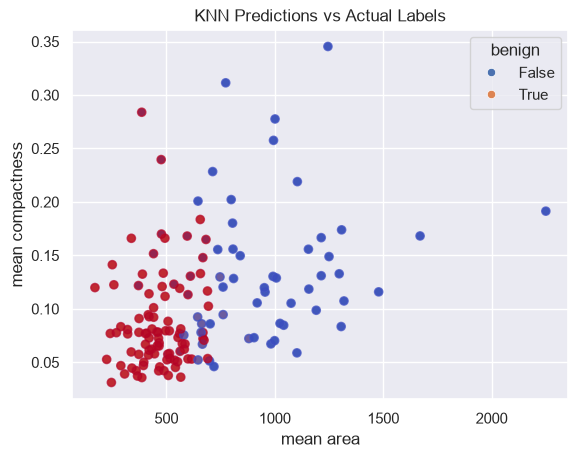

Confusion Matrix:
 [[42 13]
 [ 9 79]]


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

sns.set()

# The dataset classifies tumors into two categories (malignant and benign) and contains
# around 30 features. In the real world, you'd look at the correlations and select a subset
# of features that plays the greatest role in determining whether a tumor is malignant or not.
# However, for the sake of simplicity, we'll pick a couple at random. We must encode
# categorical data for it to be interpreted by the model (i.e. malignant = 0, benign = 1).

# 1. Load the dataset
breast_cancer = load_breast_cancer()

X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
X = X[['mean area', 'mean compactness']]

y = pd.Categorical.from_codes(breast_cancer.target, breast_cancer.target_names)
y = pd.get_dummies(y, drop_first=True)

# 2. Split into train and test sets
# By default, train_test_split sets aside 25% of the samples for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# 3. Train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

# 4. Make predictions
y_pred = knn.predict(X_test)

# 5. Visualize actual vs predicted classes
sns.scatterplot(
    x='mean area',
    y='mean compactness',
    hue='benign',
    data=X_test.join(y_test, how='outer')
)

plt.scatter(
    X_test['mean area'],
    X_test['mean compactness'],
    c=y_pred,
    cmap='coolwarm',
    alpha=0.7
)

plt.title("KNN Predictions vs Actual Labels")
plt.show()

# 6. Evaluate with a confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)